In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

In [21]:
import zipfile
import os
from google.colab import files

uploaded = files.upload()

zip_filename = list(uploaded.keys())[0]
with zipfile.ZipFile(zip_filename, 'r') as z:
    z.extractall('.')
    print("Files extracted:", z.namelist())

csv_file = [f for f in os.listdir('.') if f.endswith('.csv')][0]
df = pd.read_csv(csv_file)
print(df.shape)
print(df.head())

Saving archive (3).zip to archive (3).zip
Files extracted: ['spam_ham_dataset.csv']
(5171, 4)
   Unnamed: 0 label                                               text  \
0         605   ham  Subject: enron methanol ; meter # : 988291\r\n...   
1        2349   ham  Subject: hpl nom for january 9 , 2001\r\n( see...   
2        3624   ham  Subject: neon retreat\r\nho ho ho , we ' re ar...   
3        4685  spam  Subject: photoshop , windows , office . cheap ...   
4        2030   ham  Subject: re : indian springs\r\nthis deal is t...   

   label_num  
0          0  
1          0  
2          0  
3          1  
4          0  


label
ham     3672
spam    1499
Name: count, dtype: int64

Percentage:
label
ham     71.01141
spam    28.98859
Name: proportion, dtype: float64


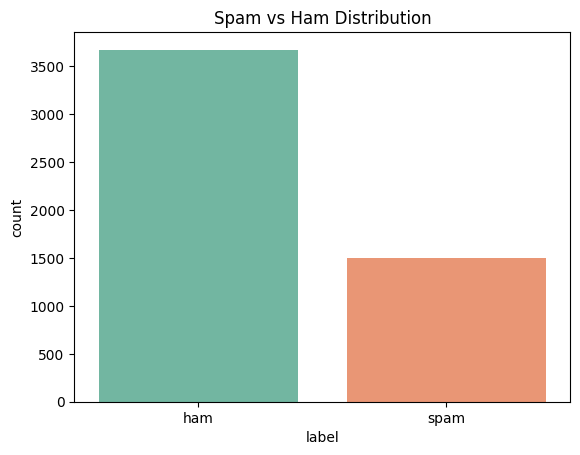


Average email length:
label
ham      977.008170
spam    1223.256171
Name: text_length, dtype: float64


In [22]:
print(df['label'].value_counts())
print("\nPercentage:")
print(df['label'].value_counts(normalize=True) * 100)

sns.countplot(x='label', data=df, palette='Set2')
plt.title('Spam vs Ham Distribution')
plt.show()

df['text_length'] = df['text'].apply(len)
print("\nAverage email length:")
print(df.groupby('label')['text_length'].mean())

In [23]:
import re
import string
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import nltk
nltk.download('stopwords')

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    stop_words = set(stopwords.words('english'))
    tokens = text.split()
    tokens = [w for w in tokens if w not in stop_words]
    stemmer = PorterStemmer()
    tokens = [stemmer.stem(w) for w in tokens]
    return ' '.join(tokens)

df['cleaned_text'] = df['text'].apply(clean_text)

print("Before cleaning:")
print(df['text'][0][:200])
print("\nAfter cleaning:")
print(df['cleaned_text'][0][:200])

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Before cleaning:
Subject: enron methanol ; meter # : 988291
this is a follow up to the note i gave you on monday , 4 / 3 / 00 { preliminary
flow data provided by daren } .
please override pop ' s daily volume { pre

After cleaning:
subject enron methanol meter follow note gave monday preliminari flow data provid daren pleas overrid pop daili volum present zero reflect daili activ obtain ga control chang need asap econom purpos


In [24]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

X = df['cleaned_text']
y = df['label_num']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

bow_vectorizer = CountVectorizer(max_features=5000)
X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)

tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("BOW shape:", X_train_bow.shape)
print("TF-IDF shape:", X_train_tfidf.shape)

Train size: 4136, Test size: 1035
BOW shape: (4136, 5000)
TF-IDF shape: (4136, 5000)


In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Naive Bayes': MultinomialNB(),
    'SVM': LinearSVC()
}

results = {}

for name, model in models.items():
    model.fit(X_train_bow, y_train)
    bow_acc = accuracy_score(y_test, model.predict(X_test_bow))

    model.fit(X_train_tfidf, y_train)
    tfidf_acc = accuracy_score(y_test, model.predict(X_test_tfidf))

    results[name] = {'BOW': round(bow_acc*100, 2), 'TF-IDF': round(tfidf_acc*100, 2)}
    print(f"{name} -> BOW: {bow_acc*100:.2f}% | TF-IDF: {tfidf_acc*100:.2f}%")

Logistic Regression -> BOW: 98.07% | TF-IDF: 98.16%
Naive Bayes -> BOW: 96.04% | TF-IDF: 95.56%
SVM -> BOW: 97.00% | TF-IDF: 98.36%


In [26]:
!pip install gensim -q
from gensim.models import Word2Vec

tokenized = [text.split() for text in X_train]
w2v_model = Word2Vec(sentences=tokenized, vector_size=100, window=5, min_count=1, workers=4)

def get_w2v_vector(text, model):
    words = text.split()
    vectors = [model.wv[w] for w in words if w in model.wv]
    if vectors:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(100)

X_train_w2v = np.array([get_w2v_vector(text, w2v_model) for text in X_train])
X_test_w2v = np.array([get_w2v_vector(text, w2v_model) for text in X_test])

print("Word2Vec shape:", X_train_w2v.shape)

for name, model in models.items():
    if name == 'Naive Bayes':
        continue
    model.fit(X_train_w2v, y_train)
    acc = accuracy_score(y_test, model.predict(X_test_w2v))
    results[name]['Word2Vec'] = round(acc*100, 2)
    print(f"{name} -> Word2Vec: {acc*100:.2f}%")

Word2Vec shape: (4136, 100)
Logistic Regression -> Word2Vec: 94.30%
SVM -> Word2Vec: 95.07%


In [27]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

X_train_nn = X_train_tfidf.toarray()
X_test_nn = X_test_tfidf.toarray()

model_nn = Sequential([
    Dense(256, activation='relu', input_shape=(5000,)),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model_nn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = model_nn.fit(
    X_train_nn, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

nn_acc = model_nn.evaluate(X_test_nn, y_test, verbose=0)[1]
print(f"\nNeural Network Accuracy: {nn_acc*100:.2f}%")

Epoch 1/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 11s 60ms/step - accuracy: 0.8845 - loss: 0.2406 - val_accuracy: 0.9807 - val_loss: 0.0591
Epoch 2/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 7s 56ms/step - accuracy: 0.9925 - loss: 0.0215 - val_accuracy: 0.9758 - val_loss: 0.0555
Epoch 3/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 10s 57ms/step - accuracy: 0.9989 - loss: 0.0052 - val_accuracy: 0.9855 - val_loss: 0.0556
Epoch 4/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 7s 55ms/step - accuracy: 1.0000 - loss: 9.4515e-04 - val_accuracy: 0.9855 - val_loss: 0.0579
Epoch 5/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 1.0000 - loss: 5.2866e-04 - val_accuracy: 0.9855 - val_loss: 0.0603
Epoch 6/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 1.0000 - loss: 3.2255e-04 - val_accuracy: 0.9855 - val_loss: 0.0642
Epoch 7/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 1.0000 - loss: 2.4271e-04 - val_accuracy: 0.9855 - val_loss: 0.0661
Epoch 8/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 1.0000 - loss:

Model                          BOW   TF-IDF   Word2Vec
Logistic Regression         98.07%   98.16%      94.3%
Naive Bayes                 96.04%   95.56%         -%
SVM                          97.0%   98.36%     95.07%
Neural Network                   —   98.36%          —


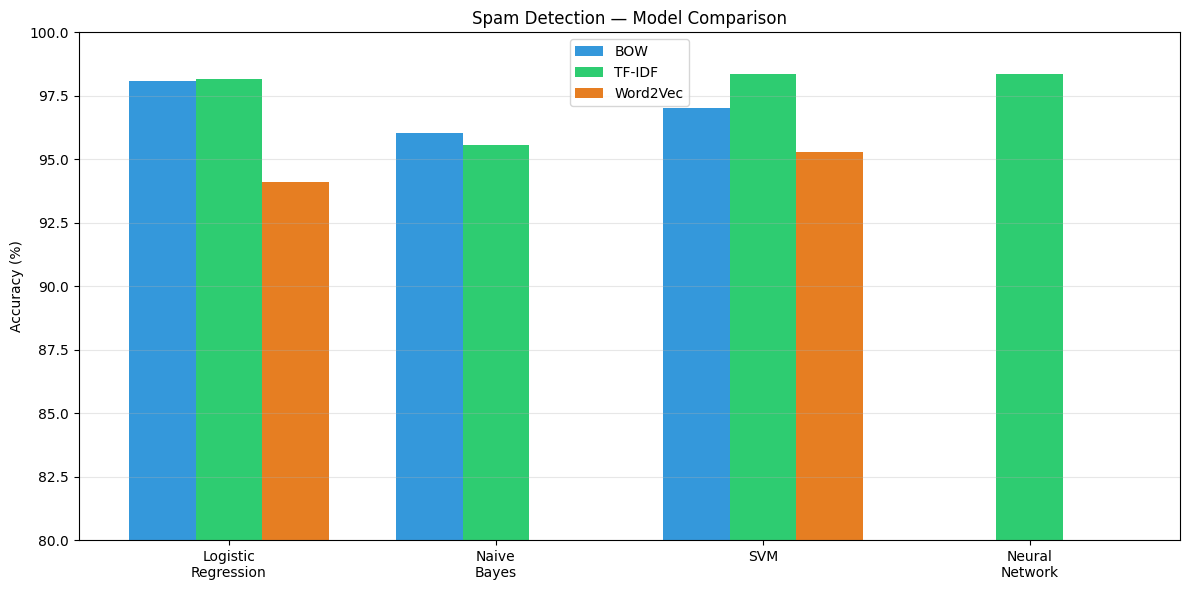

In [28]:
print("=" * 60)
print(f"{'Model':<25} {'BOW':>8} {'TF-IDF':>8} {'Word2Vec':>10}")
print("=" * 60)
for name, scores in results.items():
    bow = f"{scores.get('BOW', '-')}%"
    tfidf = f"{scores.get('TF-IDF', '-')}%"
    w2v = f"{scores.get('Word2Vec', '-')}%"
    print(f"{name:<25} {bow:>8} {tfidf:>8} {w2v:>10}")
print(f"{'Neural Network':<25} {'—':>8} {'98.36%':>8} {'—':>10}")
print("=" * 60)

models_names = ['Logistic\nRegression', 'Naive\nBayes', 'SVM', 'Neural\nNetwork']
bow_scores =   [98.07, 96.04, 97.00, 0]
tfidf_scores = [98.16, 95.56, 98.36, 98.36]
w2v_scores =   [94.11, 0, 95.27, 0]

x = np.arange(len(models_names))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width, bow_scores, width, label='BOW', color='#3498DB')
ax.bar(x, tfidf_scores, width, label='TF-IDF', color='#2ECC71')
ax.bar(x + width, w2v_scores, width, label='Word2Vec', color='#E67E22')

ax.set_ylabel('Accuracy (%)')
ax.set_title('Spam Detection — Model Comparison')
ax.set_xticks(x)
ax.set_xticklabels(models_names)
ax.set_ylim(80, 100)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()